# 记忆的进化：GRU与长期依赖问题


## 介绍

## 知识点


## 环境版本

In [1]:
from util import show_version

show_version()

+------+----------------------------------------------------------------------------------------+
| Info |                                   《动手学人工智能》                                   |
+------+----------------------------------------------------------------------------------------+
| 作者 |                                       吾辈亦有感                                       |
| 哔站 |                      https://space.bilibili.com/3461565265217538                       |
| 定位 |      基于'从零构建'的理念，用实战降低学习大模型的门槛，帮助程序员快速入门大模型。      |
| 愿景 | 若我的经验能让你的AI学习之路走的更容易一点，让你的生活变得更美好，我将倍感荣幸！祝好😄 |
+------+----------------------------------------------------------------------------------------+

环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 观察数据

In [2]:
# 打开文件并读取前5行
from util import show_first_n_lines

show_first_n_lines('../dataset/shopping_comments/train.txt', 5)

,行数,内容
0,1,1\t布料一般，尺码合适，总体来说还算可以
1,2,1\t裤子收到了 质量超级好 穿起来也很正式男朋友很喜欢
2,3,0\t根本就不是纯棉的，客服还一再跟我死硬，说就是纯棉的！
3,4,0\t看着还行，可是不怎么好用 怀疑是不是假的
4,5,1\t裤子质量非常好 特别满意的一次购物 卖家服务超好


## 自定义分词器

1. 如何将文字转化为计算机可以理解的数字？
2. 如何处理长短不一的文本？

In [3]:
class SimpleTokenizer:
    def __init__(self, pad_at_beginning=False):
        """
        初始化简单分词器
        """
        # 特殊token
        self.pad_token = '[PAD]'
        self.unk_token = '[UNK]'
        self.pad_at_beginning = pad_at_beginning
        
        # 特殊token ID
        self.pad_token_id = 0
        self.unk_token_id = 1

        # 构建词汇表
        self.vocab = {
            self.pad_token: self.pad_token_id,
            self.unk_token: self.unk_token_id,
        }

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def build_vocab(self, texts):
        """
        根据文本构建词汇表
        """
        for text in texts:
            words = list(text)  # 将每个汉字作为独立token

            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = self.vocab_size
                    self.ids_to_tokens[self.vocab_size] = word
                    self.vocab_size += 1

    def build_vocab_from_file(self, file_path):
        """
        从文件中构建词汇表
        """
        texts = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                texts.append(line.strip())

        self.build_vocab(texts)

    def encode(self, text):
        """
        将文本编码为token ids
        """
        tokens = list(text)

        # 转换为IDs
        token_ids = []
        for token in tokens:
            if token in self.vocab:
                token_ids.append(self.vocab[token])
            else:
                token_ids.append(self.unk_token_id)

        return token_ids

    def decode(self, token_ids):
        """
        将token ids解码为文本
        """
        tokens = []
        for token_id in token_ids:
            if token_id in self.ids_to_tokens:
                token = self.ids_to_tokens[token_id]
                # 过滤特殊token（可根据需要调整）
                if token not in [self.pad_token]:
                    tokens.append(token)

        return ''.join(tokens)

    def pad_sequences(self, sequences, max_length, pad_at_beginning=False):
        """
        对序列进行填充或截断
        
        Args:
            sequences: 序列列表
            max_length: 最大长度
            pad_at_beginning: 是否在序列开头填充，默认为False（在末尾填充）
        """
        padded_sequences = []
    
        for seq in sequences:
            if len(seq) > max_length:
                # 截断
                if pad_at_beginning:
                    # 从开头截断
                    padded_seq = seq[len(seq) - max_length:]
                else:
                    # 从末尾截断
                    padded_seq = seq[:max_length]
            else:
                # 填充
                pad_length = max_length - len(seq)
                padding = [self.pad_token_id] * pad_length
                if pad_at_beginning:
                    # 在开头填充
                    padded_seq = padding + seq
                else:
                    # 在末尾填充
                    padded_seq = seq + padding
    
            padded_sequences.append(padded_seq)
    
        return padded_sequences


    def __call__(self, texts, max_length=128):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        # 填充或截断到统一长度
        padded_token_ids = self.pad_sequences(all_token_ids, max_length, self.pad_at_beginning)

        if is_single_text:
            padded_token_ids = padded_token_ids[0]

        return padded_token_ids

In [4]:
# 使用 print_table 展示结果
from util import print_table

# 示例文本
sample_texts = [
    "动手学 AI",
    "吾辈亦有感"
]

# 创建分词器实例
tokenizer = SimpleTokenizer()

# 构建词汇表
tokenizer.build_vocab(sample_texts)

# 构建词汇表信息表格
vocab_info = [["Vocabulary Size", tokenizer.vocab_size]]
print_table("分词器信息", ["项目", "值"], vocab_info)

# 显示词表
print_table("字符到ID的映射表", field_names=["Token", "Token ID"], data=[
    [token, tokenizer.vocab[token]] for token in tokenizer.vocab])


分词器信息：
+-----------------+----+
|       项目      | 值 |
+-----------------+----+
| Vocabulary Size | 13 |
+-----------------+----+

字符到ID的映射表：
+-------+----------+
| Token | Token ID |
+-------+----------+
| [PAD] |    0     |
| [UNK] |    1     |
|   动  |    2     |
|   手  |    3     |
|   学  |    4     |
|       |    5     |
|   A   |    6     |
|   I   |    7     |
|   吾  |    8     |
|   辈  |    9     |
|   亦  |    10    |
|   有  |    11    |
|   感  |    12    |
+-------+----------+


In [5]:
# 使用示例
max_length = 6

# 示例文本
sample_texts.append("动手学人工智能")

# 编码文本
encoded_token_ids = tokenizer(sample_texts, max_length=max_length)

print_table("编码结果", ["原始文本", "编码序列", "解码结果"], [
    [sample_texts[i], encoded_token_ids[i], tokenizer.decode(encoded_token_ids[i])] for i in range(len(sample_texts))
])


编码结果：
+----------------+-----------------------+-----------------------+
|    原始文本    |        编码序列       |        解码结果       |
+----------------+-----------------------+-----------------------+
|   动手学 AI    |   [2, 3, 4, 5, 6, 7]  |       动手学 AI       |
|   吾辈亦有感   | [8, 9, 10, 11, 12, 0] |       吾辈亦有感      |
| 动手学人工智能 |   [2, 3, 4, 1, 1, 1]  | 动手学[UNK][UNK][UNK] |
+----------------+-----------------------+-----------------------+


## 数据转换

In [6]:
import torch
import torch.nn.functional as F


class TextTransform:
    def __init__(self, tokenizer, max_length=20, vocab_size=None):
        self.tokenizer = tokenizer
        self.max_length = max_length
        # 需要知道词汇表大小来创建 one-hot 向量
        self.vocab_size = vocab_size or tokenizer.vocab_size

    def __call__(self, text):
        # 使用 tokenizer 对文本进行编码，并自动完成截断与填充
        input_ids = self.tokenizer(
            text,
            max_length=self.max_length,  # 最大序列长度
        )

        # 将 input_ids 转换为 one-hot 向量
        # 注意：这里假设 input_ids 是一个列表或者一维张量
        # 如果 input_ids 不是 tensor，则转换为 tensor
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.long)

        return input_ids

In [7]:
# TextTransform 使用示例
text_transform = TextTransform(tokenizer, max_length=10)

sample_text = "动手学 AI"
encoded_token_ids = text_transform(sample_text)
print("Encoded Shape:", encoded_token_ids.shape)
print("Encoded:", encoded_token_ids)

Encoded Shape: torch.Size([10])
Encoded: tensor([2, 3, 4, 5, 6, 7, 0, 0, 0, 0])


## 构造数据集

In [8]:
import torch
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = self.transform(text)
    
        return {
            "input_ids": input_ids,
            "labels": torch.tensor(label, dtype=torch.long)
        }

    @classmethod
    def from_file(cls, file_path, transform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []
        labels = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    # 使用制表符分割
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        label = int(parts[0])  # 第一列是标签
                        text = '\t'.join(parts[1:])  # 剩余部分是文本（处理文本中可能包含制表符的情况）
                        texts.append(text)
                        labels.append(label)

        # 创建数据集实例
        return cls(texts, labels, transform)

In [9]:
from pprint import pprint

file_path = "../dataset/shopping_comments/dev.txt"
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file(file_path)
transform = TextTransform(tokenizer, max_length=10)

dataset = TextClassificationDataset.from_file(file_path, transform=transform)

pprint(dataset[:2]["input_ids"].shape)

torch.Size([2, 10])


## 初始化数据模组

In [10]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size=32, transform=None,
                 train_data_file="../dataset/shopping_comments/dev.txt",
                 val_data_file="../dataset/shopping_comments/dev.txt",
                 test_data_file="../dataset/shopping_comments/test.txt"):
        super().__init__()

        self.train_data_file = train_data_file
        self.val_data_file = val_data_file
        self.test_data_file = test_data_file

        self.test_dataset = None
        self.val_dataset = None
        self.train_dataset = None

        self.batch_size = batch_size
        self.transform = transform

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        pass

    def setup(self, stage=None):
        self.train_dataset = TextClassificationDataset.from_file(self.train_data_file,
                                                                 transform=self.transform)

        self.val_dataset = TextClassificationDataset.from_file(
            self.val_data_file,
            transform=self.transform
        )

        self.test_dataset = TextClassificationDataset.from_file(
            self.test_data_file,
            transform=self.transform
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

In [11]:
max_length = 20
# 创建 DataModule 实例并设置
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file("../dataset/shopping_comments/dev.txt")
transform = TextTransform(tokenizer, max_length=max_length)
text_datamodule = TextDataModule(batch_size=2, transform=transform)

# 调用 setup 方法初始化数据集
text_datamodule.setup()

# 获取训练数据加载器
train_loader = text_datamodule.train_dataloader()

# 打印一个批次的数据
print("打印一个批次的数据：")
for batch in train_loader:
    pprint(batch["input_ids"].shape)
    pprint(batch["labels"].shape)
    break

打印一个批次的数据：
torch.Size([2, 20])
torch.Size([2])


## 构建模型

In [12]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, vocab_size=10, hidden_size=128, num_classes=2, learning_rate=0.01, dropout_p=0.1):
        super(TextClassifier, self).__init__()
        self.learning_rate = learning_rate

        # 定义网络层
        # 嵌入层：将词索引映射到高维向量
        self.token_emb = nn.Embedding(vocab_size, hidden_size)
        # GRU层：用于处理序列数据
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        # Dropout层：防止过拟合
        self.dropout = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(hidden_size, num_classes)

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.randint(0, vocab_size, (32, 10), dtype=torch.long)

        # 标签id到标签的映射，用于预测解码
        self.label_map = None

    def forward(self, input_ids):
        """前向传播"""
        token_embeds = self.dropout(self.token_emb(input_ids))  # 嵌入并应用dropout
        gru_output, gru_hidden = self.gru(token_embeds)  # 通过GRU处理, 得到输出和隐藏状态
        
        # 取出最后一层的隐藏状态（对于单层GRU，索引为-1或0都可以）
        last_hidden = gru_hidden[-1]  # 形状: (batch_size, hidden_size)
        
        # 将最后一个时间步的特征输入到输出层
        out = self.output_layer(last_hidden)  # 形状: (batch_size, num_classes)
        
        return out



    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)
        loss = F.cross_entropy(outputs, labels)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_ids = batch["input_ids"]
        target_ids = batch["labels"]

        # 前向传播
        outputs = self(input_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': target_ids})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, label_map=None):
        """根据数据集设置标签映射"""
        self.label_map = label_map

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        # 【新增】判断输入类型并处理
        if isinstance(input_ids, list):
            input_ids = torch.stack(input_ids)  # 转换为张量

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.label_map[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.label_map[label_id] for label_id in label_ids]

In [13]:
from lightning.pytorch.utilities.model_summary import ModelSummary

model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

summary = ModelSummary(model, max_depth=-1)
print(summary)

  | Name         | Type      | Params | Mode  | FLOPs  | In sizes      | Out sizes                    
------------------------------------------------------------------------------------------------------------
0 | token_emb    | Embedding | 220 K  | train | 0      | [32, 10]      | [32, 10, 128]                
1 | gru          | GRU       | 99.1 K | train | 62.9 M | [32, 10, 128] | [[32, 10, 128], [1, 32, 128]]
2 | dropout      | Dropout   | 0      | train | 0      | [32, 10, 128] | [32, 10, 128]                
3 | output_layer | Linear    | 258    | train | 16.4 K | [32, 128]     | [32, 2]                      
------------------------------------------------------------------------------------------------------------
320 K     Trainable params
0         Non-trainable params
320 K     Total params
1.281     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
62.9 M    Total Flops


## 训练前评估

In [14]:
max_length = 30
batch_size = 32

tokenizer = SimpleTokenizer(pad_at_beginning=True)
tokenizer.build_vocab_from_file("../dataset/shopping_comments/dev.txt")
transform = TextTransform(tokenizer, max_length=max_length)

# 创建 DataModule 实例并设置
datamodule = TextDataModule(batch_size=batch_size, transform=transform)

# 创建 TextClassifier 实例并设置
model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# # 冻结嵌入层
# model.token_emb.requires_grad_(False)

trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0, enable_progress_bar=False)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


In [15]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1406.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.5153958797454834     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1406.0,
  'val_overall_acc': 0.5153958797454834}]

## 训练模型

In [16]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type      ┃ Params ┃ Mode  ┃  FLOPs ┃      In sizes ┃                     Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ token_emb    │ Embedding │  220 K │ train │      0 │      [32, 10] │                 [32, 10, 128] │
│ 1 │ gru          │ GRU       │ 99.1 K │ train │ 62.9 M │ [32, 10, 128] │ [[32, 10, 128], [1, 32, 128]] │
│ 2 │ dropout      │ Dropout   │      0 │ train │      0 │ [32, 10, 128] │                 [32, 10, 128] │
│ 3 │ output_layer │ Linear    │    258 │ train │ 16.4 K │     [32, 128] │                       [32, 2] │
└───┴──────────────┴───────────┴────────┴───────┴────────┴───────────────┴───────────────────────────────┘

Trainable params: 320 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 320 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 62.9 M

`Trainer.fit` stopped: `max_epochs=12` reached.


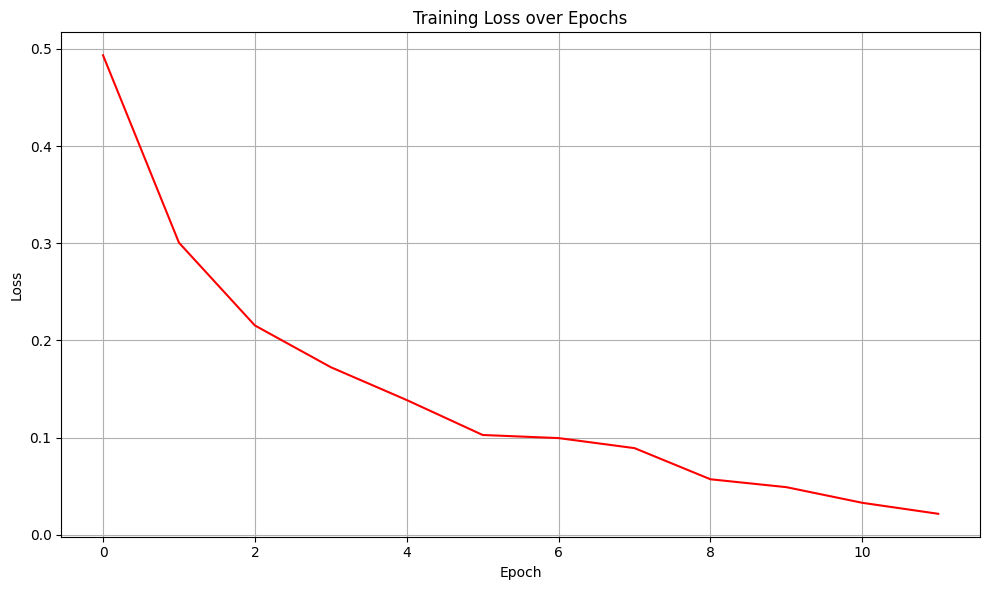

In [17]:
from util import plot_training_loss

plot_training_loss(model.train_epoch_losses)

In [18]:
from util import show_table

show_table(model.eval_accuracies)

,epoch,总样本数,正确样本数,准确率
0,0,2728,2395,0.8779
1,1,2728,2547,0.9337
2,2,2728,2590,0.9494
3,3,2728,2621,0.9608
4,4,2728,2671,0.9791
5,5,2728,2679,0.9820
6,6,2728,2662,0.9758
7,7,2728,2698,0.9890
8,8,2728,2706,0.9919
9,9,2728,2716,0.9956


## 训练后评估

In [19]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2723.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.9981671571731567     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 2723.0,
  'val_overall_acc': 0.9981671571731567}]

## 使用模型进行预测

In [20]:
model.setup_label_map(label_map={0: "负面", 1: "正面"})

from util import print_classification_results

# 1. 准备需要预测的文本（长短不一）
new_texts = [
    # 短文本（5-10个字符）
    "非常好",
    "质量差",
    "推荐购买",
    "不建议买",

    # 中等长度文本（10-20个字符）
    "这个产品还不错",
    "物流速度太慢了",
    "性价比很高值得推荐",

    # 长文本（20个字符以上）
    "包装很精美，产品和描述一致，非常满意这次购物体验",
    "卖家服务态度不好，发货速度慢，产品质量也不如预期",
    "虽然价格有点贵，但是品质确实不错，使用效果很满意"
]

true_labels = [1, 0, 1, 0, 1, 0, 1, 1, 0, 1]


# 2. 使用与训练时统一的 transform 方法对文本进行处理
input_ids = []
for text in new_texts:
    # 使用训练时相同的 transform 方法
    transformed = transform(text)
    input_ids.append(transformed)


# 3. 使用模型进行预测
predictions, decoded_predictions, probabilities = model.predict(input_ids)

# 4. 输出预测结果
print_classification_results(new_texts, true_labels, predictions, probabilities, model.label_map)


🎯 分类预测结果 (准确率: 10/10 = 100.00%)：
+--------------------------------------------------+----------+----------+----------+------+
|                       输入                       | 真实标签 | 预测标签 | 最高概率 | 标记 |
+--------------------------------------------------+----------+----------+----------+------+
|                      非常好                      |   正面   |   正面   |  0.9939  |  ☑   |
|                      质量差                      |   负面   |   负面   |  0.9861  |  ☑   |
|                     推荐购买                     |   正面   |   正面   |  0.9928  |  ☑   |
|                     不建议买                     |   负面   |   负面   |  0.9759  |  ☑   |
|                  这个产品还不错                  |   正面   |   正面   |  0.9980  |  ☑   |
|                  物流速度太慢了                  |   负面   |   负面   |  0.9959  |  ☑   |
|                性价比很高值得推荐                |   正面   |   正面   |  0.9994  |  ☑   |
| 包装很精美，产品和描述一致，非常满意这次购物体验 |   正面   |   正面   |  0.9883  |  ☑   |
| 卖家服务态度不好，发货速度慢，产品质量也不如预期 |   负面   |   负面   |  0.99

## 模型测试

In [21]:
from util import print_red

datamodule2 = TextDataModule(batch_size=batch_size, transform=transform,
                             train_data_file="../dataset/shopping_comments/dev.txt",
                             val_data_file="../dataset/shopping_comments/test.txt")

print_red("在训练集上评估：")
trainer.validate(model=model, datamodule=datamodule)

print_red("在测试集上评估：")
trainer.validate(model=model, datamodule=datamodule2)

在训练集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2723.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.9981671571731567     │
└───────────────────────────┴───────────────────────────┘

在测试集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2486.0           │
│       total_samples       │          2789.0           │
│      val_overall_acc      │    0.8913589119911194     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2789.0,
  'total_correct': 2486.0,
  'val_overall_acc': 0.8913589119911194}]

## 拓展阅读

## 存在的问题

思考一下，引出下一章